In [19]:
import os
from google.colab import drive

import numpy as np
import pandas as pd

import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import files


In [11]:
ruta_drive = '/content/drive'
drive.mount(ruta_drive)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Semilla

In [3]:
import random

# Establecer semilla para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Cargando datasets

## direccion carpetas

In [ ]:
#Mano abierta
mano_abierta_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/mano_abierta/"

#Mano cerrada
mano_cerrada_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/mano_cerrada/"

#Indice
indice_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/indice_arriba/"

#Paz
paz_dir = ruta_drive +"/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/paz/"


directorios = {
  0: mano_abierta_dir,
  1: mano_cerrada_dir,
  2: indice_dir,
  3: paz_dir
}

## Mostrar algunas imagenes

Cantidad de imagenes, mano abierta 982
Cantidad de imagenes, mano cerrada 887
Cantidad de imagenes, indice 758
Cantidad de imagenes, paz 615


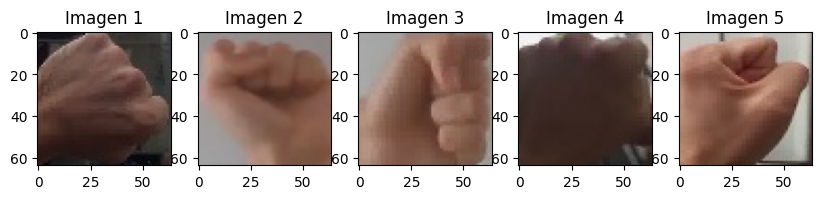

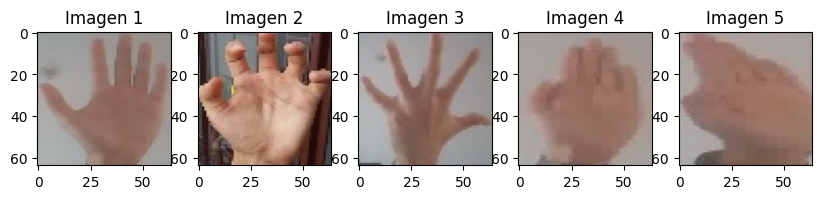

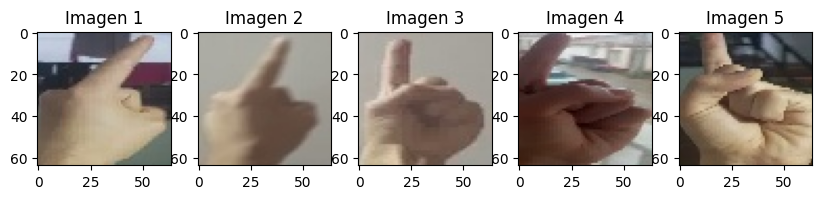

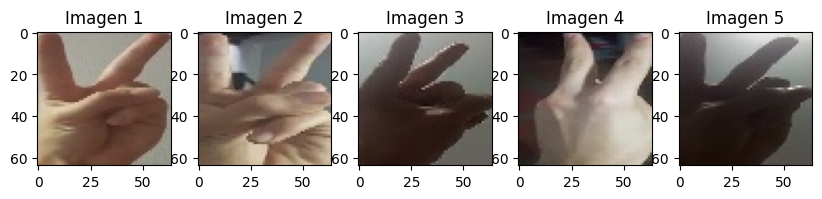

In [ ]:


imagenes_mano_abierta = os.listdir(mano_abierta_dir)
imagenes_mano_cerrada = os.listdir(mano_cerrada_dir)
imagenes_indice = os.listdir(indice_dir)
imagenes_paz = os.listdir(paz_dir)

print("Cantidad de imagenes, mano abierta", len(imagenes_mano_abierta))
print("Cantidad de imagenes, mano cerrada", len(imagenes_mano_cerrada))
print("Cantidad de imagenes, indice", len(imagenes_indice))
print("Cantidad de imagenes, paz", len(imagenes_paz))

def mostrar_imagen(ruta, imagenes):
  plt.figure(figsize=(10, 5))
  for i, nombre_archivo in enumerate(imagenes):
    plt.subplot(1, len(imagenes), i + 1)
    plt.imshow(mpimg.imread(ruta + nombre_archivo))
    plt.title(f"Imagen {i+1}")

  plt.show()


# 3. Dibujar las imágenes usando la ruta completa
mostrar_imagen(mano_cerrada_dir, imagenes_mano_cerrada[:5])
mostrar_imagen(mano_abierta_dir, imagenes_mano_abierta[:5])
mostrar_imagen(indice_dir, imagenes_indice[:5])
mostrar_imagen(paz_dir, imagenes_paz[:5])


## Carga, Redimensionamiento y construcción de Arrays

In [ ]:
IMG_SIZE = 64
X = [] # Aquí guardaremos las imágenes (características)
y = [] # Aquí guardaremos las etiquetas (labels)

print("Iniciando carga de imágenes...")

for etiqueta, carpeta in directorios.items():
  # Listar todos los archivos en la carpeta
  archivos = os.listdir(carpeta)
  print(f"Cargando clase {etiqueta} desde: {carpeta} ({len(archivos)} imágenes encontradas)")

  for archivo in archivos:
    ruta_imagen = os.path.join(carpeta, archivo)

    # 1. Leer imagen
    img = cv2.imread(ruta_imagen)

    if img is not None:
      # 2. Convertir de BGR a RGB
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      # 3. Redimensionar a 64x64
      img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

      # 4. Agregar a las listas
      X.append(img_resized)
      y.append(etiqueta)

print(f"\nTotal de imágenes procesadas: {len(X)}")

Iniciando carga de imágenes...
Cargando clase 0 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/mano_abierta/ (982 imágenes encontradas)
Cargando clase 1 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/mano_cerrada/ (887 imágenes encontradas)
Cargando clase 2 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/indice_arriba/ (758 imágenes encontradas)
Cargando clase 3 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/paz/ (615 imágenes encontradas)

Total de imágenes procesadas: 3242


## Conversión a Tensores, Normalización y Codificación

In [ ]:
# Convertir listas a arrays de NumPy
X = np.array(X)
y = np.array(y)

# Normalizar los datos
X = X.astype('float32') / 255.0

# Codificación One-Hot para las etiquetas
# Ej: La clase 2 se convierte en [0, 0, 1, 0]
y_categorical = to_categorical(y, num_classes=4)

print("Forma del tensor X (imágenes):", X.shape)
# Debería imprimir algo como (3242, 64, 64, 3)
print("Forma del tensor y (etiquetas):", y_categorical.shape)
# Debería imprimir (3242, 4)

Forma del tensor X (imágenes): (3242, 64, 64, 3)
Forma del tensor y (etiquetas): (3242, 4)


## División del Dataset (Train / Test)

In [ ]:
# Dividir en datos de entrenamiento y prueba
# stratify=y_categorical asegura que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical)

print(f"Imágenes para entrenamiento: {X_train.shape[0]}")
print(f"Imágenes para validación/prueba: {X_test.shape[0]}")

Imágenes para entrenamiento: 2593
Imágenes para validación/prueba: 649


## Guardar los tensores

In [ ]:
ruta_guardado = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado.npz"

print("Comprimiendo y guardando tensores en Drive. Esto puede tomar un minuto...")

# Guardamos todos los arrays en un solo archivo comprimido
np.savez_compressed(ruta_guardado,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test)

print(f"¡Datos guardados exitosamente en: {ruta_guardado}!")

Comprimiendo y guardando tensores en Drive. Esto puede tomar un minuto...
¡Datos guardados exitosamente en: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado.npz!


## Cargar tensores

In [3]:
ruta_guardado = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado.npz"

print("Cargando tensores desde Drive...")
# Cargar el archivo comprimido
datos = np.load(ruta_guardado)

# Extraer los arreglos
X_train = datos['X_train']
X_test = datos['X_test']
y_train = datos['y_train']
y_test = datos['y_test']

print("¡Datos cargados al instante!")
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)

Cargando tensores desde Drive...
¡Datos cargados al instante!
Forma de X_train: (2593, 64, 64, 3)
Forma de y_train: (2593, 4)


# CNNv1

Para la construcción de la cnn se va a usar una arquitectura vgg simplificada

## Estructura CNN

In [ ]:
modelo_cnn = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(64,64,3)),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation='relu'),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Dense(units=4, activation='softmax')
])

modelo_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compilación CNN

In [ ]:
from tensorflow.keras.optimizers import Adam
optimizador = Adam(learning_rate=0.0001)
modelo_cnn.compile(
    optimizer= optimizador,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Entrenamiento

In [ ]:
# 1. Configurar la Parada Temprana (Early Stopping)
# Monitoreamos la pérdida en el conjunto de validación (val_loss)
# Si no mejora durante 5 épocas seguidas (patience=5), detenemos el entrenamiento
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True, # Nos quedamos con los pesos de la mejor época
    verbose=1
)

# 2. Hiperparámetros de entrenamiento
EPOCAS = 30       # Número máximo de veces que el modelo verá todo el dataset
TAMANO_LOTE = 32  # Cantidad de imágenes que procesa a la vez antes de actualizar los pesos

print("Iniciando el entrenamiento de la CNN...")

# 3. Entrenar el modelo
historial = modelo_cnn.fit(
    x=X_train,
    y=y_train,
    batch_size=TAMANO_LOTE,
    epochs=EPOCAS,
    validation_data=(X_test, y_test), # Usamos el 20% que separamos para validar
    callbacks=[early_stopping],
    verbose=1
)

print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento de la CNN...
Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.3000 - loss: 1.3777 - val_accuracy: 0.3035 - val_loss: 1.3713
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3039 - loss: 1.3726 - val_accuracy: 0.3035 - val_loss: 1.3710
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3027 - loss: 1.3718 - val_accuracy: 0.3035 - val_loss: 1.3707
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3012 - loss: 1.3713 - val_accuracy: 0.3035 - val_loss: 1.3702
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3031 - loss: 1.3704 - val_accuracy: 0.3035 - val_loss: 1.3694
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3012 - loss: 1.3701 - val_accuracy: 0.3035 - val_loss: 1.3659
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3039 - loss: 1.3610 - val_accuracy: 0.3035 - val_loss: 1.3523
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3683 - loss: 

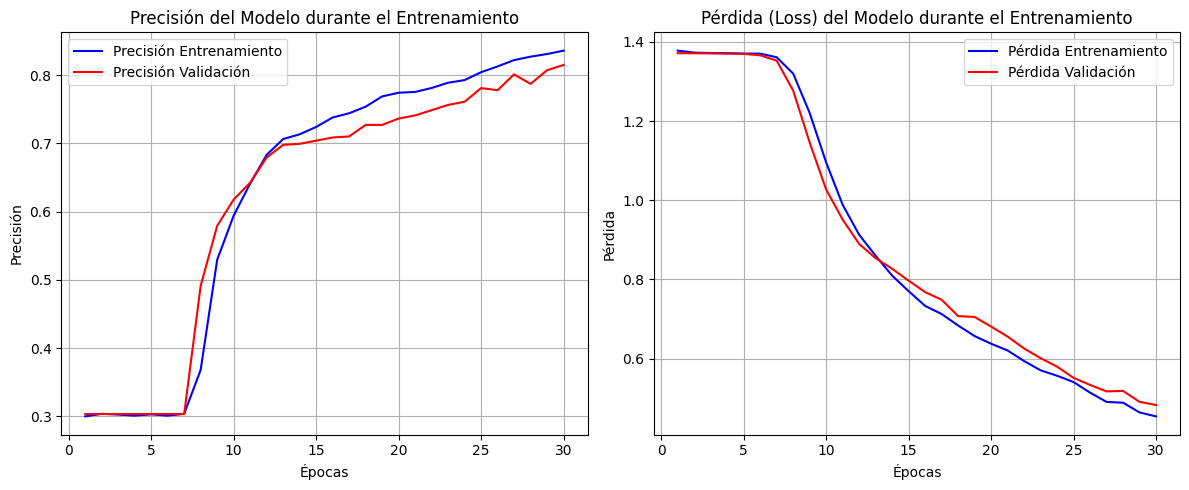

In [ ]:
# Extraer datos del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas_reales = range(1, len(acc) + 1)

# Crear la figura
plt.figure(figsize=(12, 5))

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epocas_reales, acc, 'b-', label='Exactitud Entrenamiento')
plt.plot(epocas_reales, val_acc, 'r-', label='Exactitud Validación')
plt.title('Exactitud del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas_reales, loss, 'b-', label='Pérdida Entrenamiento')
plt.plot(epocas_reales, val_loss, 'r-', label='Pérdida Validación')
plt.title('Pérdida (Loss) del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

     Abierta       0.79      0.92      0.85       197
     Cerrada       0.88      0.75      0.81       177
      Índice       0.80      0.80      0.80       152
         Paz       0.80      0.76      0.78       123

    accuracy                           0.82       649
   macro avg       0.82      0.81      0.81       649
weighted avg       0.82      0.82      0.81       649



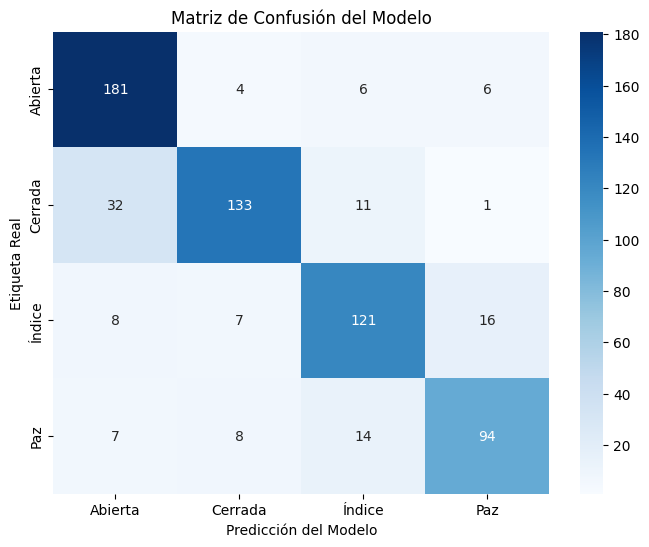

In [ ]:
# 1. Hacer predicciones con el conjunto de prueba
predicciones = modelo_cnn.predict(X_test)

# 2. Convertir las predicciones y etiquetas reales de One-Hot a índices (0, 1, 2, 3)
y_pred_clases = np.argmax(predicciones, axis=1)
y_real_clases = np.argmax(y_test, axis=1)

# Nombres de las clases para las gráficas
nombres_clases = ['Abierta', 'Cerrada', 'Índice', 'Paz']

# 3. Generar el Reporte de Clasificación (Precision, Recall, F1-Score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real_clases, y_pred_clases, target_names=nombres_clases))

# 4. Generar y Graficar la Matriz de Confusión
matriz_conf = confusion_matrix(y_real_clases, y_pred_clases)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión del Modelo')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

## Guardar y descargar el modelo

In [ ]:
from google.colab import files

# 1. Definir la ruta con el formato .keras (es el estándar actual más eficiente)
ruta_modelo_final = ruta_drive + "/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_gestos_v1.keras"

# 2. Guardar la arquitectura, los pesos y la configuración de entrenamiento
modelo_cnn.save(ruta_modelo_final)
print(f"✅ Modelo guardado exitosamente en tu Google Drive: {ruta_modelo_final}")

# 3. Descargar el archivo a tu computadora local
print("Iniciando descarga al equipo local...")
files.download(ruta_modelo_final)

✅ Modelo guardado exitosamente en tu Google Drive: /content/drive/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_gestos_v1.keras
Iniciando descarga al equipo local...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Probando el modelo con una imagen nueva

Por favor, sube la foto de prueba:


Saving paz_3.jpeg to paz_3.jpeg

Procesando imagen: paz_3.jpeg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


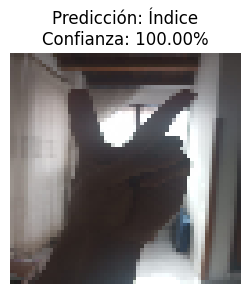


Probabilidades por clase:
- Abierta: 0.00%
- Cerrada: 0.00%
- Índice: 100.00%
- Paz: 0.00%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Por favor, sube la foto de prueba:")
# 1. Widget interactivo para subir la imagen
uploaded = files.upload()

# Nombres de nuestras clases para interpretar el resultado
nombres_clases = ['Abierta', 'Cerrada', 'Índice', 'Paz']

for nombre_archivo in uploaded.keys():
    print(f"\nProcesando imagen: {nombre_archivo}...")

    # 2. Cargar la imagen con OpenCV
    img = cv2.imread(nombre_archivo)

    if img is None:
        print("Error: No se pudo cargar la imagen.")
        continue

    # 3. Preprocesamiento EXACTO al usado en el entrenamiento
    # Convertir de BGR a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar a 64x64
    img_resized = cv2.resize(img_rgb, (64, 64))

    # Normalizar valores entre 0 y 1
    img_normalized = img_resized.astype('float32') / 255.0

    # 4. Ajuste de dimensiones (Crucial)
    # La CNN espera un lote (batch): (batch, height, width, channels)
    img_input = np.expand_dims(img_normalized, axis=0)

    # 5. Realizar la predicción
    prediccion_proba = modelo_cnn.predict(img_input)
    clase_index = np.argmax(prediccion_proba)
    confianza = np.max(prediccion_proba) * 100
    gesto_predicho = nombres_clases[clase_index]

    # 6. Mostrar el resultado visualmente con la imagen REDIMENSIONADA
    plt.figure(figsize=(3, 3))
    plt.imshow(img_resized)  # Mostramos la imagen de 64x64 que procesará el modelo
    plt.title(f'Predicción: {gesto_predicho}\nConfianza: {confianza:.2f}%')
    plt.axis('off')
    plt.show()

    # Mostrar las probabilidades para todas las clases
    print("\nProbabilidades por clase:")
    for i, nombre in enumerate(nombres_clases):
        print(f"- {nombre}: {prediccion_proba[0][i]*100:.2f}%")

# CNNv2 (Data augmentation)

Para la construcción de la cnn se va a usar una arquitectura vgg simplificada

## Estructura CNN

In [ ]:
modelo_cnn_v2 = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(64, 64,3)),
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(factor=0.05),
  tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
  tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
  tf.keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(units=128, activation='relu'),
  tf.keras.layers.Dropout(0.25),
  tf.keras.layers.Dense(units=4, activation='softmax')
])

modelo_cnn_v2.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 64, 64, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,716 (2.61 MB)

 Trainable params: 683,716 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compilación CNN

In [ ]:
from tensorflow.keras.optimizers import Adam
optimizador = Adam(learning_rate=0.0001)
modelo_cnn_v2.compile(
    optimizer= optimizador,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Entrenamiento

In [ ]:
# 1. Configurar la Parada Temprana (Early Stopping)
# Monitoreamos la pérdida en el conjunto de validación (val_loss)
# Si no mejora durante 5 épocas seguidas (patience=5), detenemos el entrenamiento
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True, # Nos quedamos con los pesos de la mejor época
    verbose=1
)

# 2. Hiperparámetros de entrenamiento
EPOCAS = 45       # Número máximo de veces que el modelo verá todo el dataset
TAMANO_LOTE = 32  # Cantidad de imágenes que procesa a la vez antes de actualizar los pesos

print("Iniciando el entrenamiento de la CNN...")

# 3. Entrenar el modelo
historial = modelo_cnn_v2.fit(
    x=X_train,
    y=y_train,
    batch_size=TAMANO_LOTE,
    epochs=EPOCAS,
    validation_data=(X_test, y_test), # Usamos el 20% que separamos para validar
    callbacks=[early_stopping],
    verbose=1
)

print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento de la CNN...
Epoch 1/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 299ms/step - accuracy: 0.3024 - loss: 1.3780 - val_accuracy: 0.3035 - val_loss: 1.3709
Epoch 2/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.3035 - loss: 1.3719 - val_accuracy: 0.3035 - val_loss: 1.3709
Epoch 3/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 26s 315ms/step - accuracy: 0.3020 - loss: 1.3723 - val_accuracy: 0.3035 - val_loss: 1.3700
Epoch 4/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 305ms/step - accuracy: 0.3024 - loss: 1.3701 - val_accuracy: 0.3035 - val_loss: 1.3685
Epoch 5/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 281ms/step - accuracy: 0.3043 - loss: 1.3681 - val_accuracy: 0.3035 - val_loss: 1.3633
Epoch 6/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 305ms/step - accuracy: 0.3251 - loss: 1.3567 - val_accuracy: 0.3051 - val_loss: 1.3543
Epoch 7/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 300ms/step - accuracy: 0.3899 - loss: 1.3314 - val_accuracy: 0.4499 - val_loss: 1.2989
Epoch 8/45
82/82 ━━━━━━━━━━━━━━━━━━━━ 25s 307ms/step - ac

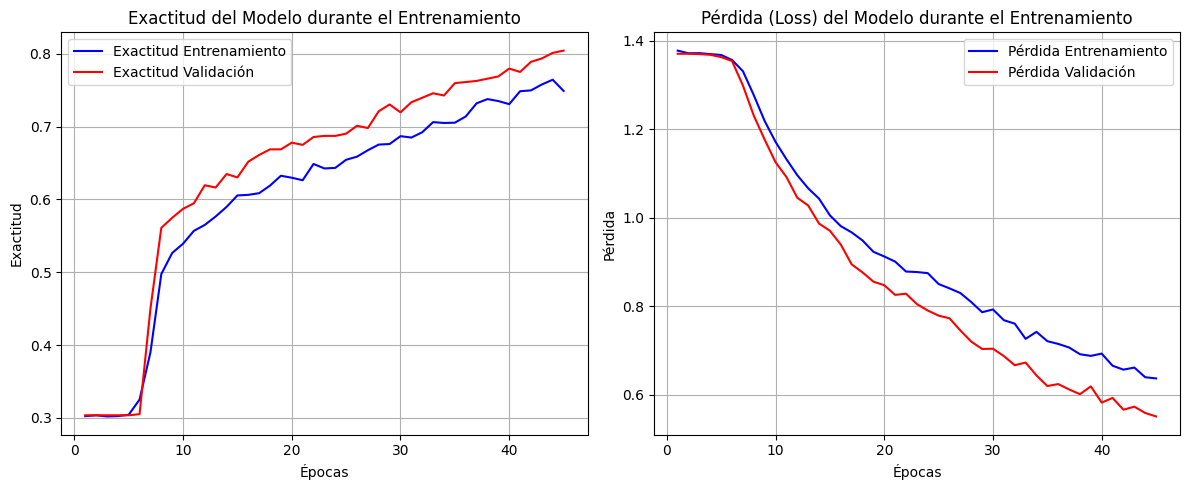

In [ ]:
# Extraer datos del historial
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
epocas_reales = range(1, len(acc) + 1)

# Crear la figura
plt.figure(figsize=(12, 5))

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epocas_reales, acc, 'b-', label='Exactitud Entrenamiento')
plt.plot(epocas_reales, val_acc, 'r-', label='Exactitud Validación')
plt.title('Exactitud del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas_reales, loss, 'b-', label='Pérdida Entrenamiento')
plt.plot(epocas_reales, val_loss, 'r-', label='Pérdida Validación')
plt.title('Pérdida (Loss) del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

     Abierta       0.79      0.92      0.85       197
     Cerrada       0.85      0.79      0.82       177
      Índice       0.80      0.79      0.79       152
         Paz       0.76      0.66      0.71       123

    accuracy                           0.80       649
   macro avg       0.80      0.79      0.79       649
weighted avg       0.80      0.80      0.80       649



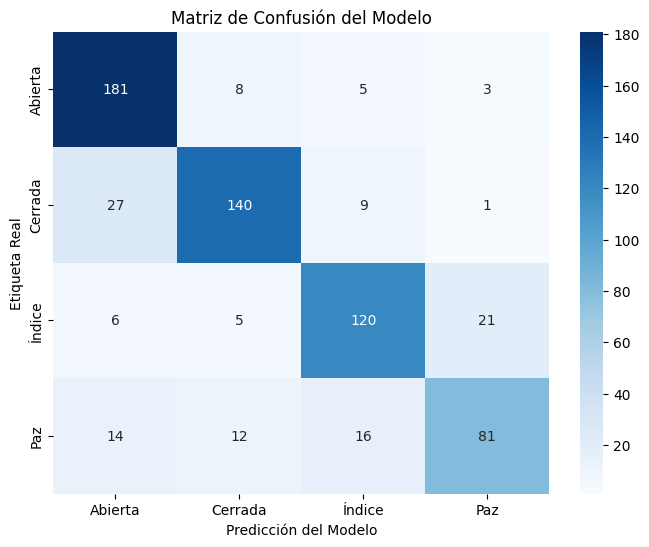

In [ ]:
# 1. Hacer predicciones con el conjunto de prueba
predicciones = modelo_cnn_v2.predict(X_test)

# 2. Convertir las predicciones y etiquetas reales de One-Hot a índices (0, 1, 2, 3)
y_pred_clases = np.argmax(predicciones, axis=1)
y_real_clases = np.argmax(y_test, axis=1)

# Nombres de las clases para las gráficas
nombres_clases = ['Abierta', 'Cerrada', 'Índice', 'Paz']

# 3. Generar el Reporte de Clasificación (Precision, Recall, F1-Score)
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_real_clases, y_pred_clases, target_names=nombres_clases))

# 4. Generar y Graficar la Matriz de Confusión
matriz_conf = confusion_matrix(y_real_clases, y_pred_clases)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión del Modelo')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.show()

## Guardar y descargar el modelo

In [ ]:
from google.colab import files

# 1. Definir la ruta con el formato .keras (es el estándar actual más eficiente)
ruta_modelo_final = ruta_drive + "/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_gestos_v2.keras"

# 2. Guardar la arquitectura, los pesos y la configuración de entrenamiento
modelo_cnn_v2.save(ruta_modelo_final)
print(f"✅ Modelo guardado exitosamente en tu Google Drive: {ruta_modelo_final}")

# 3. Descargar el archivo a tu computadora local
print("Iniciando descarga al equipo local...")
files.download(ruta_modelo_final)

✅ Modelo guardado exitosamente en tu Google Drive: /content/drive/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_gestos_v2.keras
Iniciando descarga al equipo local...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Probando el modelo con una imagen nueva

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Por favor, sube la foto de prueba:")
# 1. Widget interactivo para subir la imagen
uploaded = files.upload()

# Nombres de nuestras clases para interpretar el resultado
nombres_clases = ['Abierta', 'Cerrada', 'Índice', 'Paz']

for nombre_archivo in uploaded.keys():
    print(f"\nProcesando imagen: {nombre_archivo}...")

    # 2. Cargar la imagen con OpenCV
    img = cv2.imread(nombre_archivo)

    if img is None:
        print("Error: No se pudo cargar la imagen.")
        continue

    # 3. Preprocesamiento EXACTO al usado en el entrenamiento
    # Convertir de BGR a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Redimensionar a 64x64
    img_resized = cv2.resize(img_rgb, (64, 64))

    # Normalizar valores entre 0 y 1
    img_normalized = img_resized.astype('float32') / 255.0

    # 4. Ajuste de dimensiones (Crucial)
    # La CNN espera un lote (batch): (batch, height, width, channels)
    img_input = np.expand_dims(img_normalized, axis=0)

    # 5. Realizar la predicción
    prediccion_proba = modelo_cnn_v2.predict(img_input)
    clase_index = np.argmax(prediccion_proba)
    confianza = np.max(prediccion_proba) * 100
    gesto_predicho = nombres_clases[clase_index]

    # 6. Mostrar el resultado visualmente con la imagen REDIMENSIONADA
    plt.figure(figsize=(3, 3))
    plt.imshow(img_resized)  # Mostramos la imagen de 64x64 que procesará el modelo
    plt.title(f'Predicción: {gesto_predicho}\nConfianza: {confianza:.2f}%')
    plt.axis('off')
    plt.show()

    # Mostrar las probabilidades para todas las clases
    print("\nProbabilidades por clase:")
    for i, nombre in enumerate(nombres_clases):
        print(f"- {nombre}: {prediccion_proba[0][i]*100:.2f}%")

Por favor, sube la foto de prueba:


# Movilenetv2

## direccion carpetas

In [12]:
#Mano abierta
mano_abierta_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/mano_abierta/"

#Mano cerrada
mano_cerrada_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/mano_cerrada/"

#Indice
indice_dir = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/indice_arriba/"

#Paz
paz_dir = ruta_drive +"/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/paz/"


directorios = {
  0: mano_abierta_dir,
  1: mano_cerrada_dir,
  2: indice_dir,
  3: paz_dir
}

## Mostrar algunas imagenes

Cantidad de imagenes, mano abierta 615
Cantidad de imagenes, mano cerrada 615
Cantidad de imagenes, indice 615
Cantidad de imagenes, paz 615


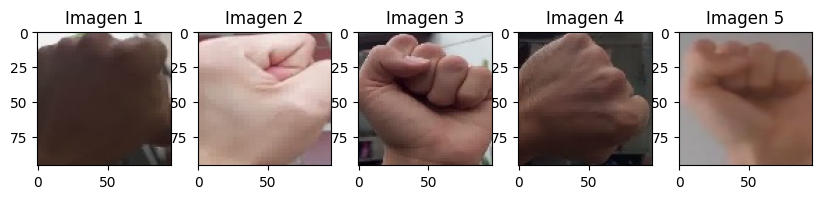

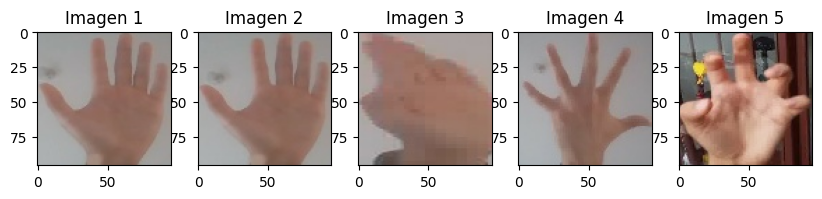

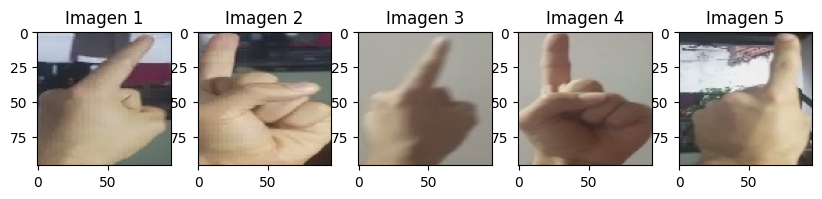

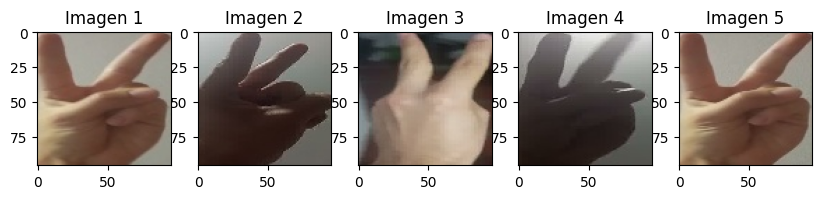

In [13]:


imagenes_mano_abierta = os.listdir(mano_abierta_dir)
imagenes_mano_cerrada = os.listdir(mano_cerrada_dir)
imagenes_indice = os.listdir(indice_dir)
imagenes_paz = os.listdir(paz_dir)

print("Cantidad de imagenes, mano abierta", len(imagenes_mano_abierta))
print("Cantidad de imagenes, mano cerrada", len(imagenes_mano_cerrada))
print("Cantidad de imagenes, indice", len(imagenes_indice))
print("Cantidad de imagenes, paz", len(imagenes_paz))

def mostrar_imagen(ruta, imagenes):
  plt.figure(figsize=(10, 5))
  for i, nombre_archivo in enumerate(imagenes):
    plt.subplot(1, len(imagenes), i + 1)
    plt.imshow(mpimg.imread(ruta + nombre_archivo))
    plt.title(f"Imagen {i+1}")

  plt.show()


# 3. Dibujar las imágenes usando la ruta completa
mostrar_imagen(mano_cerrada_dir, imagenes_mano_cerrada[:5])
mostrar_imagen(mano_abierta_dir, imagenes_mano_abierta[:5])
mostrar_imagen(indice_dir, imagenes_indice[:5])
mostrar_imagen(paz_dir, imagenes_paz[:5])


## Carga, Redimensionamiento y construcción de Arrays

In [14]:
IMG_SIZE = 96
X = [] # Aquí guardaremos las imágenes (características)
y = [] # Aquí guardaremos las etiquetas (labels)

print("Iniciando carga de imágenes...")

for etiqueta, carpeta in directorios.items():
  # Listar todos los archivos en la carpeta
  archivos = os.listdir(carpeta)
  print(f"Cargando clase {etiqueta} desde: {carpeta} ({len(archivos)} imágenes encontradas)")

  for archivo in archivos:
    ruta_imagen = os.path.join(carpeta, archivo)

    # 1. Leer imagen
    img = cv2.imread(ruta_imagen)

    if img is not None:
      # 2. Convertir de BGR a RGB
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      # 3. Redimensionar a 96x96
      img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

      # 4. Agregar a las listas
      X.append(img_resized)
      y.append(etiqueta)

print(f"\nTotal de imágenes procesadas: {len(X)}")

Iniciando carga de imágenes...
Cargando clase 0 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/mano_abierta/ (615 imágenes encontradas)
Cargando clase 1 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/mano_cerrada/ (615 imágenes encontradas)
Cargando clase 2 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/indice_arriba/ (615 imágenes encontradas)
Cargando clase 3 desde: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/96x96/paz/ (615 imágenes encontradas)

Total de imágenes procesadas: 2460


## Conversión a Tensores, Normalización y Codificación

In [15]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# 1. Convertir listas a arrays de NumPy
X = np.array(X)
y = np.array(y)

# 2. Normalización oficial para MobileNetV2 (Reemplaza al / 255.0)
X_preprocesado = preprocess_input(X)

# 3. Codificación One-Hot para las etiquetas
y_categorical = to_categorical(y, num_classes=4)

print("Forma del tensor X (imágenes):", X_preprocesado.shape)
# Ahora imprimirá: (2460, 96, 96, 3) debido al Undersampling y al nuevo tamaño

print("Forma del tensor y (etiquetas):", y_categorical.shape)
# Imprimirá: (2460, 4)


Forma del tensor X (imágenes): (2460, 96, 96, 3)
Forma del tensor y (etiquetas): (2460, 4)


## División del Dataset (Train / Test)

In [16]:
# Dividir en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocesado,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print(f"Imágenes para entrenamiento: {X_train.shape[0]}")
print(f"Imágenes para validación/prueba: {X_test.shape[0]}")

Imágenes para entrenamiento: 1968
Imágenes para validación/prueba: 492


## Guardar los tensores

In [18]:
ruta_guardado = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado_96x96.npz"

print("Comprimiendo y guardando tensores en Drive. Esto puede tomar un minuto...")

# Guardamos todos los arrays en un solo archivo comprimido
# X_train y X_test ya contienen el preprocesamiento de MobileNetV2 realizado anteriormente
np.savez_compressed(ruta_guardado,
                    X_train=X_train,
                    X_test=X_test,
                    y_train=y_train,
                    y_test=y_test)

print(f"¡Datos guardados exitosamente en: {ruta_guardado}!")

Comprimiendo y guardando tensores en Drive. Esto puede tomar un minuto...
¡Datos guardados exitosamente en: /content/drive/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado_96x96.npz!


## Cargar tensores

In [ ]:
ruta_guardado = ruta_drive + "/MyDrive/IA_II/Proyecto/01_Dataset/Dataset_Procesado/Alex/dataset_preprocesado.npz"

print("Cargando tensores desde Drive...")
# Cargar el archivo comprimido
datos = np.load(ruta_guardado)

# Extraer los arreglos
X_train = datos['X_train']
X_test = datos['X_test']
y_train = datos['y_train']
y_test = datos['y_test']

print("¡Datos cargados al instante!")
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)

Cargando tensores desde Drive...
¡Datos cargados al instante!
Forma de X_train: (2593, 64, 64, 3)
Forma de y_train: (2593, 4)


## Estructura del modelo

In [20]:
# 1. Cargar MobileNetV2 sin la capa de salida (include_top=False)
# Usamos pesos preentrenados en 'imagenet'
modelo_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# 2. Congelar el modelo base
# Esto evita que los pesos preentrenados se destruyan durante las primeras épocas
modelo_base.trainable = False

# 3. Construir la arquitectura final
modelo_tl = Sequential([
    modelo_base,

    # GlobalAveragePooling2D reduce los mapas de características a un vector 1D
    # Es mucho más eficiente que Flatten() para modelos profundos
    GlobalAveragePooling2D(),

    # Capa densa para interpretar las características de las manos
    Dense(128, activation='relu'),
    Dropout(0.3), # Previene el sobreajuste

    # Capa de salida para las 4 clases
    Dense(4, activation='softmax')
])

# 4. Compilar el modelo
modelo_tl.compile(
    optimizer=Adam(learning_rate=0.001), # Podemos usar un LR estándar ahora
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Resumen de la arquitectura de Transfer Learning:")
modelo_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Resumen de la arquitectura de Transfer Learning:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Entrenar el modelo

In [21]:
# 5. Configurar Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 6. Entrenar el modelo
print("\nIniciando el entrenamiento con Transfer Learning...")
historial_tl = modelo_tl.fit(
    X_train, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)


Iniciando el entrenamiento con Transfer Learning...
Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 51s 497ms/step - accuracy: 0.8552 - loss: 0.3650 - val_accuracy: 0.9654 - val_loss: 0.0965
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9761 - loss: 0.0763 - val_accuracy: 0.9736 - val_loss: 0.0636
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9909 - loss: 0.0343 - val_accuracy: 0.9858 - val_loss: 0.0459
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9949 - loss: 0.0204 - val_accuracy: 0.9858 - val_loss: 0.0392
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9970 - loss: 0.0172 - val_accuracy: 0.9919 - val_loss: 0.0259
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9964 - loss: 0.0165 - val_accuracy: 0.9878 - val_loss: 0.0357
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9964 - loss: 0.0132 - val_accuracy: 0.9817 - val_loss: 0.0344
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc

In [22]:
# 7. Guardar el modelo
ruta_modelo_mobilenet = "/content/drive/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_mobilenet_v1.keras"
modelo_tl.save(ruta_modelo_mobilenet)
print(f"✅ Modelo preentrenado guardado en: {ruta_modelo_mobilenet}")

✅ Modelo preentrenado guardado en: /content/drive/MyDrive/IA_II/Proyecto/03_Modelos_Guardados/Alex/modelo_mobilenet_v1.keras


## Resultados

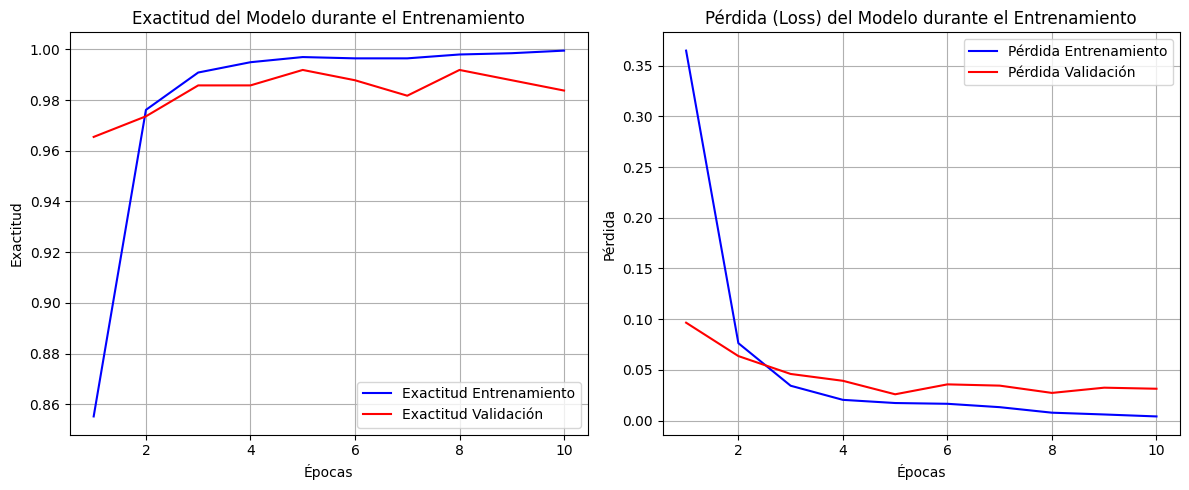

In [23]:
# Extraer datos del historial
acc = historial_tl.history['accuracy']
val_acc = historial_tl.history['val_accuracy']
loss = historial_tl.history['loss']
val_loss = historial_tl.history['val_loss']
epocas_reales = range(1, len(acc) + 1)

# Crear la figura
plt.figure(figsize=(12, 5))

# Gráfica de Exactitud (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epocas_reales, acc, 'b-', label='Exactitud Entrenamiento')
plt.plot(epocas_reales, val_acc, 'r-', label='Exactitud Validación')
plt.title('Exactitud del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epocas_reales, loss, 'b-', label='Pérdida Entrenamiento')
plt.plot(epocas_reales, val_loss, 'r-', label='Pérdida Validación')
plt.title('Pérdida (Loss) del Modelo durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step
--- REPORTE DE CLASIFICACIÓN (MobileNetV2) ---
              precision    recall  f1-score   support

     Abierta       1.00      0.99      1.00       123
     Cerrada       0.99      1.00      1.00       123
      Índice       0.98      0.99      0.99       123
         Paz       0.99      0.98      0.99       123

    accuracy                           0.99       492
   macro avg       0.99      0.99      0.99       492
weighted avg       0.99      0.99      0.99       492



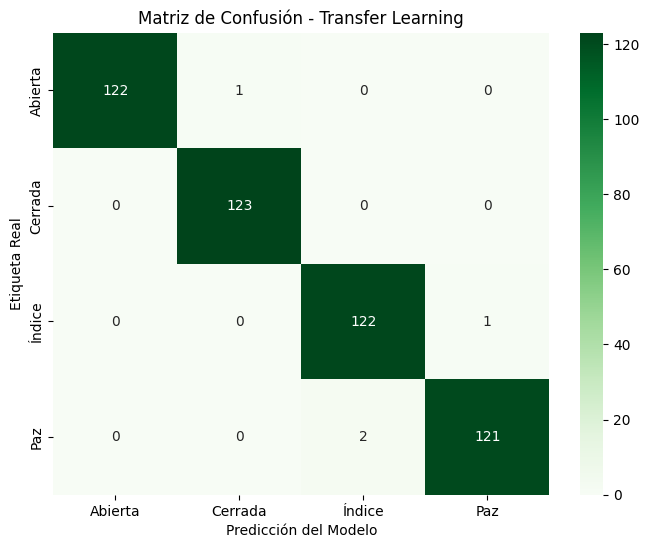

In [24]:
# Hacer predicciones
predicciones = modelo_tl.predict(X_test)
y_pred_clases = np.argmax(predicciones, axis=1)
y_real_clases = np.argmax(y_test, axis=1)

nombres_clases = ['Abierta', 'Cerrada', 'Índice', 'Paz']

# Reporte
print("--- REPORTE DE CLASIFICACIÓN (MobileNetV2) ---")
print(classification_report(y_real_clases, y_pred_clases, target_names=nombres_clases))

# Matriz de Confusión
matriz_conf = confusion_matrix(y_real_clases, y_pred_clases)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Greens',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Transfer Learning')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()